In [1]:
!pip install tensorflow matplotlib optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.1 MB/s eta 0:00:00


In [12]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D

print(f"TensorFlow versi: {tf.__version__}")
print("Import berhasil!")

TensorFlow versi: 2.20.0
Import berhasil!


In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

print(f"x_train shape : {x_train.shape}")
print(f"x_test shape  : {x_test.shape}")
print(f"Range pixel   : {x_train.min()} - {x_train.max()}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
x_train shape : (50000, 32, 32, 3)
x_test shape  : (10000, 32, 32, 3)
Range pixel   : 0.0 - 1.0


/tmp/ipykernel_953/3926783606.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(CLASS_NAMES[int(y_train[i])])


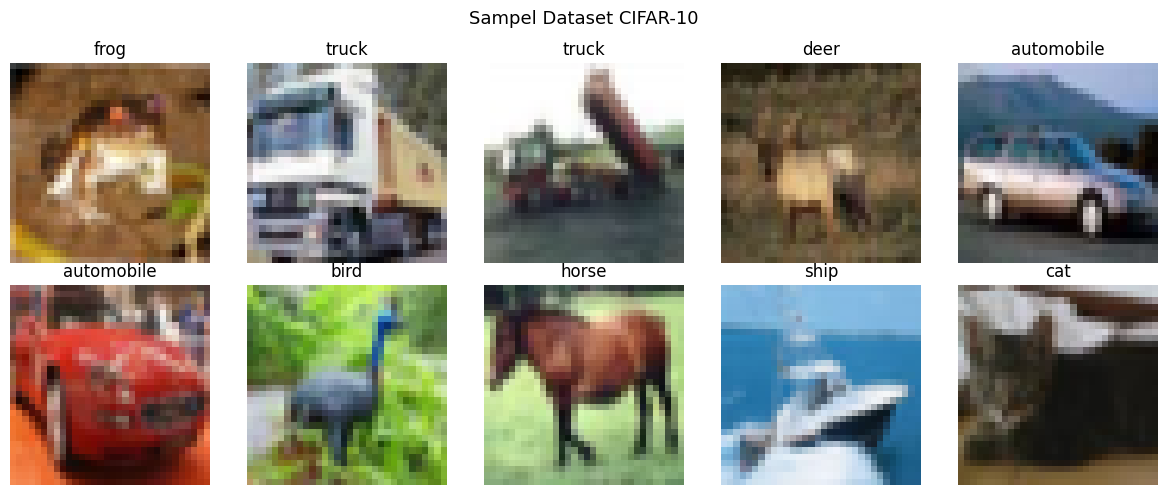

In [4]:
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[int(y_train[i])])
    ax.axis('off')
plt.suptitle('Sampel Dataset CIFAR-10', fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

model_vgg = Model(inputs=base_model.input, outputs=output)
model_vgg.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_vgg = model_vgg.fit(x_train, y_train,
                             validation_data=(x_test, y_test),
                             epochs=5, batch_size=32)

loss, acc = model_vgg.evaluate(x_test, y_test, verbose=0)
print(f"VGG16 - Test Accuracy: {acc:.4f} | Test Loss: {loss:.4f}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.5208 - loss: 1.3704 - val_accuracy: 0.5563 - val_loss: 1.2621
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5811 - loss: 1.1957 - val_accuracy: 0.5785 - val_loss: 1.2038
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6014 - loss: 1.1422 - val_accuracy: 0.5881 - val_loss: 1.1790
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6162 - loss: 1.0998 - val_accuracy: 0.5951 - val_loss: 1.1570
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6253 - loss: 1.0692 - val_accuracy: 0.5946 - val_loss: 1.1594
VGG16 - Test Accuracy: 0.5946 | Test Loss: 1.1594


In [6]:
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_resnet.trainable = False

x = GlobalAveragePooling2D()(base_resnet.output)
x = Dense(128, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

model_resnet = Model(inputs=base_resnet.input, outputs=output)
model_resnet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_resnet = model_resnet.fit(x_train, y_train,
                                   validation_data=(x_test, y_test),
                                   epochs=5, batch_size=32)

loss, acc = model_resnet.evaluate(x_test, y_test, verbose=0)
print(f"ResNet50 - Test Accuracy: {acc:.4f} | Test Loss: {loss:.4f}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.2549 - loss: 2.0282 - val_accuracy: 0.2839 - val_loss: 1.8983
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.3207 - loss: 1.8715 - val_accuracy: 0.3540 - val_loss: 1.8042
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.3419 - loss: 1.8157 - val_accuracy: 0.3375 - val_loss: 1.8203
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.3538 - loss: 1.7871 - val_accuracy: 0.3474 - val_loss: 1.8282
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.3661 - loss: 1.7582 - val_accuracy: 0.3835 - val_loss: 1.7225
ResNet50 - Test Accuracy: 0.3835 | Test Loss: 1.7225


In [7]:
# Load raw data dulu
(x_train_raw, y_train), (x_test_raw, y_test) = cifar10.load_data()

# Untuk VGG16 — normalisasi biasa /255
x_train_vgg = x_train_raw.astype('float32') / 255.0
x_test_vgg  = x_test_raw.astype('float32')  / 255.0

# Untuk ResNet50 — preprocessing khusus
x_train_resnet = resnet_preprocess(x_train_raw.astype('float32'))
x_test_resnet  = resnet_preprocess(x_test_raw.astype('float32'))

print(f"VGG16   range: {x_train_vgg.min():.2f} - {x_train_vgg.max():.2f}")
print(f"ResNet  range: {x_train_resnet.min():.2f} - {x_train_resnet.max():.2f}")

VGG16   range: 0.00 - 1.00
ResNet  range: -123.68 - 151.06


In [8]:
history_vgg = model_vgg.fit(
    x_train_vgg, y_train,
    validation_data=(x_test_vgg, y_test),
    epochs=5, batch_size=32
)

loss, acc = model_vgg.evaluate(x_test_vgg, y_test, verbose=1)
print(f"VGG16 - Test Accuracy: {acc:.4f} | Test Loss: {loss:.4f}")

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6368 - loss: 1.0377 - val_accuracy: 0.6045 - val_loss: 1.1318
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6465 - loss: 1.0134 - val_accuracy: 0.6005 - val_loss: 1.1476
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6533 - loss: 0.9880 - val_accuracy: 0.6041 - val_loss: 1.1473
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6607 - loss: 0.9665 - val_accuracy: 0.6054 - val_loss: 1.1372
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6664 - loss: 0.9440 - val_accuracy: 0.6131 - val_loss: 1.1264
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6131 - loss: 1.1264
VGG16 - Test Accuracy: 0.6131 | Test Loss: 1.1264


In [9]:
history_resnet = model_resnet.fit(
    x_train_resnet, y_train,
    validation_data=(x_test_resnet, y_test),
    epochs=5, batch_size=32
)

loss, acc = model_resnet.evaluate(x_test_resnet, y_test, verbose=0)
print(f"ResNet50 - Test Accuracy: {acc:.4f} | Test Loss: {loss:.4f}")

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5991 - loss: 1.1850 - val_accuracy: 0.6485 - val_loss: 1.0103
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6773 - loss: 0.9210 - val_accuracy: 0.6658 - val_loss: 0.9744
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7023 - loss: 0.8500 - val_accuracy: 0.6649 - val_loss: 0.9755
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7220 - loss: 0.7947 - val_accuracy: 0.6651 - val_loss: 0.9820
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7379 - loss: 0.7500 - val_accuracy: 0.6660 - val_loss: 1.0029
ResNet50 - Test Accuracy: 0.6660 | Test Loss: 1.0029


In [ ]:
def objective(trial):
    # Hyperparameter yang dicari
    lr      = trial.suggest_categorical('lr', [0.0001, 0.001, 0.005])
    batch   = trial.suggest_categorical('batch_size', [16, 32, 64])
    epochs  = trial.suggest_categorical('epochs', [5, 10, 20])

    # Build model
    base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    base.trainable = False
    x = Flatten()(base.output)
    x = Dense(128, activation='relu')(x)
    out = Dense(10, activation='softmax')(x)
    model = Model(inputs=base.input, outputs=out)
    model.compile(optimizer=Adam(lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    h = model.fit(x_train_vgg, y_train,
                  validation_data=(x_test_vgg, y_test),
                  epochs=epochs, batch_size=batch, verbose=1)

    return max(h.history['val_accuracy'])

# Jalankan 10 trial saja dulu
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=27)

print('\n===== Hasil Optuna — VGG16 =====')
print(f'Best Val Accuracy : {study.best_value:.4f}')
print(f'Best Params       : {study.best_params}')

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.3767 - loss: 1.8330 - val_accuracy: 0.4656 - val_loss: 1.5648
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5005 - loss: 1.4700 - val_accuracy: 0.5139 - val_loss: 1.4258
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5317 - loss: 1.3723 - val_accuracy: 0.5329 - val_loss: 1.3640
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5476 - loss: 1.3196 - val_accuracy: 0.5448 - val_loss: 1.3230
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5599 - loss: 1.2827 - val_accuracy: 0.5514 - val_loss: 1.2961
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5678 - loss: 1.2553 - val_accuracy: 0.5597 - val_loss: 1.2741
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5761 - loss: 1.2332 - val_accuracy: 0.5643 - val_loss: 1.2567
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5816 - loss: 1.2152 - 

In [ ]:
def objective_resnet(trial):
    lr     = trial.suggest_categorical('lr', [0.0001, 0.001, 0.005])
    batch  = trial.suggest_categorical('batch_size', [16, 32, 64])
    epochs = trial.suggest_categorical('epochs', [5, 10, 20])

    print(f'Trial {trial.number} → lr={lr}, batch={batch}, epochs={epochs}')

    base = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    base.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(128, activation='relu')(x)
    out = Dense(10, activation='softmax')(x)
    model = Model(inputs=base.input, outputs=out)
    model.compile(optimizer=Adam(lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    h = model.fit(x_train_resnet, y_train,
                  validation_data=(x_test_resnet, y_test),
                  epochs=epochs, batch_size=batch, verbose=1)

    return max(h.history['val_accuracy'])

study_resnet = optuna.create_study(direction='maximize')
study_resnet.optimize(objective_resnet, n_trials=27)

print('\n===== Hasil Optuna — ResNet50 =====')
print(f'Best Val Accuracy : {study_resnet.best_value:.4f}')
print(f'Best Params       : {study_resnet.best_params}')